In [1]:
from IPython import display
# this should be done better, see line 3
from IPython.display import clear_output
import matplotlib.pyplot as plt
import importlib
from signalSoup import CAg, Band
from tqdm import tqdm 
import graphviz

# Signal Soup: sharedness vs. code alignment #

A communicative environment CEnv is made up of signals. CEnv is an environment as it is not permanent: it can be modified by agents but potentially also by non-agentive events (e.g. random perturbations). In particular, a communicative agent CAg is able to interact with the environment by processing signals and replacing them. Signals can be represented in various ways, e.g. bits, but in the following we use $26$ lower letters to compose words. Also, the signal word lenght $wl$ may vary: as here we use $wl = 3$, then there are $26^{3} = 17576$ possible signals. Figure shows signals represented as note shapes: agents process signals.

![Agents and environment](agentsAndEnv.drawio.png)

## The agent ##

### Model ###
A CAg is capable of retrieving a signal from CEnv and to replace it in CEnv by dispatching a new signal. A CAg can interact directly only with CEnv.


![Agent](agent.drawio.png)

In order to retrieve a signal a CAg is provided with a set of detectors, each defining a signal type to be matched by that signal token. In order to dispatch a signal, the same agent is provided with a set of effectors defining the type of the signal token to be dispatched. Each detector is coupled with an effector, the coupling defining a sign function. Given our previous assumptions, a sign function is thus a mapping $d \to e$, where $d$ and $e$ are defined as character triples.
 Each sign function has an associated integer value, representing its relevance. The relevance has a maximum threshold, above which it is not incremented anymore. A CAg has a fixed memory, meant as the maximum lenght of the sign function list. Once it is exceeded, a random sign function is deleted from the ones having lowest relevance.

A CAg inspects the communicative environment in search of a signal. There are two cases:

1. if a signal which type is matched among the detectors is found, then the excited detector trigger its relative effector. The incoming signal in the environment is replaced by a new one, created following the effector's type. The relevance of the sign function is incremented by 1 unit.

2. if no matchable signal is found, then two random signals from the environment are considered by the agent that are used to create types for a new detector and a new effector. They are bound in a new sign function, and assigned a relevance $= 1$.

In the following, we create a CAg `a`, a custom environment `sr`, then provide the agent with 3 detectors and three effectors, coupled into three sign functions, all having an associate value $= 0$. We *retrieve*, that is, provide the Agent the environment, and *count*: in the dictionary `d` keys are related to indices in the environment, where the associated list is a list of indices of matching detectors in detectors. Dictionary `d` does not include 1 because it goes unmatched. Then, we *check*: as there is a matched word in surrounding environment (more than one), the agent *responds*: a random matching word is selected, its matching detector triggered, so that the related effector dispatch a new word that replaces the matched one (here the first  `xvg`, becoming `ggg`). The third sign function (`xvg` $\to$ `ggg`) is rewarded with a relevance $= 1$.  

In [38]:
a = CAg()
sr = 'xvg hju xvg bzi'.split()
a.detectors = 'xvg bzi xvg'.split()
a.effectors = 'eee fff ggg'.split()
a.values = [0,0,0]
a.retrieve(sr)
d = a.count()
print(d)
print(a.surrounding)
a.check(d)
print(a.values)
print(a.surrounding)

{0: [0, 2], 2: [0, 2], 3: [1]}
['xvg', 'hju', 'xvg', 'bzi']
[0, 0, 1]
['xvg', 'hju', 'ggg', 'bzi']


In the following block, the CAg `b` has no matching detectors, so it *adapts*: it expands its detectors and effectors by adding a new sign function coupling a detector to an effector by borrowing the types from two signals found in the environment (respectively, `xvg` and `hju`)). The new sign function `xvg` $\to$ `hju` is rewarded with a relevance $= 1$ but the environment is not modified.

In [42]:
b = CAg()
sr = 'xvg hju xvg bzi'.split()
b.detectors = 'aaa bbb ccc'.split()
b.effectors = 'eee fff ggg'.split()
b.values = [0,0,0]
b.retrieve(sr)
d = b.count()
print(d)
print(b.surrounding)
b.check(d)
print(b.surrounding)
print(b.detectors)
print(b.effectors)
print(b.values)

{}
['xvg', 'hju', 'xvg', 'bzi']
['xvg', 'hju', 'xvg', 'bzi']
['aaa', 'bbb', 'ccc', 'xvg']
['eee', 'fff', 'ggg', 'hju']
[0, 0, 0, 1]


We can draw the agent, in this case `a`, and inspect its structure. In the first graph, detectors are labelled in white, effectors in black, the arrows go from effectors to detectors and are labelled with their relative relevances. We can also plot a topological representation (second graph), that shows how in this case the same detector type (even if represented effectively by two detectors) allows to trigger two different effectors.

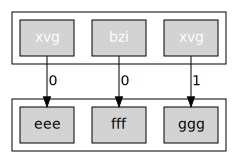

In [43]:
a.plot_agent()

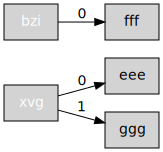

In [44]:
a.plot_topology()

### Discussion ###
CAgs are modelled after Holland's proposal for adaptive agents. Indeed, the couple detector/effector comes from biology. Yet, it is seems apt to represent the "ecological" interaction with an environment, be it a communicative one. The focus here is pragmatic, as sign function are schemas or rules prescribing the action to be performed when a certain situation occurs. The edge connecting couples of detector and effector types could also be interpreted as a shortcut to more complex topologies. The "meaning" of a sign vehicle, the signified of a signifier, is the way in which the latter is responded, by producing another signal.
Note also that action is mandatory once triggered by a detection. In the context of a communicative environment, this could be described as a forced Gricean cooperation. The new signal in output is not added to the CEnv, rather it replaces the input one: communication is meant as a sequential process in which last "moves" count more than hsitory. Also, this aspect captures fainting signals such as in oral communication.  
When created from scratch, the sign function follows complete, strict, arbitrariness. Yet, by associating two signals from the communicative environment, the agent implies that signals have been created by other agents, and that they result from a behaviour which is analogous to its one. In short, other agents should be able to detect and to generate the signals in the environment. A new sign function is thus a wild guess, but assuming as a hypothesis a minimalistic theory of the mind (similar to the Obverter model). When a new sign function is created, it is not immediately run (i.e. producing a signal) because the agent tries to learn from a failure.
The fixed memory size is meant as a biologically-motivated constraint that requires and at the same time permits the relevance scoring. In relation to the environment, the agent is exploring and exploiting it, rather than be forced to cope with single signal.
It can be observed that the agent implements the three features that are typical of complex adaptive systems: performance (moment-by-moment capabilities), credit-assignment (rating the usefulness of available capabilities), rule-discovery (generating new capabilities) (Holland).

## Population ##

### Model ###
A population of agents is a *band*. Band's members interacts through the environment by sequential random access. Each CAg is supposed to interact with other communicative agents only through the shared communicative environment, which is accessible to retrieve and dispatch/replace signals. That is, at every turn a CAg is randomly selected to inspect the environment as described above. If the selected CAg found a match for the detector the matched signal is replaced. CEnv is then available for a successive inspection by another CAg. At initialization phase, a band is randomly assembled by specifying its member size $n$ (plus eventual other parameters, e.g. word lenght). Each CAg is provided with only one sign function, created by coupling randomly made-up signal type, and associated with a relevance $= 0$.
All the members of the band share the same environment CEnv. The latter is constructed with random words and has a default size of $n$.

### Discussion ###
The notion of band refers to the basic idea of a small population sharing the same communicative environment. The communicative environment has a fixed size equal to the band's size as it is the result of the sum of their communicative actions. We assume that no previous knowledge of the environment is given to the agents. The environment is continuously updated as a result of the interaction of agents.

In the following we create a band `b` with 20 CAgs and run $2000$ turns.

In [14]:
b = Band(20)
print(b.surrounding)
#b.plot_band()

['wdj', 'jfp', 'ybc', 'cbo', 'huj', 'inw', 'dhh', 'ewt', 'esu', 'bqf', 'ngt', 'mcf', 'wdm', 'zug', 'owi', 'qry', 'cmo', 'qtv', 'ufz', 'gni']


In [15]:
for i in range(2000):
    b.turn()
    print(set(b.surrounding))


{'inw', 'ngt', 'ybc', 'wdj', 'zug', 'ewt', 'dhh', 'bqf', 'qry', 'wdm', 'cmo', 'owi', 'cbo', 'huj', 'ufz', 'mcf', 'esu', 'gni', 'qtv', 'jfp'}
{'inw', 'ngt', 'ybc', 'wdj', 'zug', 'ewt', 'dhh', 'bqf', 'qry', 'wdm', 'cmo', 'owi', 'cbo', 'huj', 'ufz', 'mcf', 'esu', 'gni', 'qtv', 'jfp'}
{'inw', 'ngt', 'ybc', 'wdj', 'zug', 'ewt', 'dhh', 'bqf', 'qry', 'wdm', 'cmo', 'owi', 'cbo', 'huj', 'ufz', 'mcf', 'esu', 'gni', 'qtv', 'jfp'}
{'inw', 'ngt', 'ybc', 'wdj', 'zug', 'ewt', 'dhh', 'bqf', 'qry', 'wdm', 'cmo', 'owi', 'cbo', 'huj', 'ufz', 'mcf', 'esu', 'gni', 'qtv', 'jfp'}
{'inw', 'ngt', 'ybc', 'wdj', 'zug', 'ewt', 'dhh', 'bqf', 'qry', 'wdm', 'owi', 'cbo', 'huj', 'ufz', 'mcf', 'esu', 'gni', 'qtv', 'jfp'}
{'inw', 'ngt', 'ybc', 'wdj', 'zug', 'ewt', 'dhh', 'bqf', 'qry', 'wdm', 'owi', 'cbo', 'huj', 'ufz', 'mcf', 'esu', 'gni', 'qtv', 'jfp'}
{'inw', 'ngt', 'ybc', 'wdj', 'zug', 'ewt', 'dhh', 'bqf', 'qry', 'wdm', 'owi', 'cbo', 'huj', 'ufz', 'mcf', 'esu', 'gni', 'qtv', 'jfp'}
{'inw', 'ngt', 'ybc', 'wdj', 'zug'

In [35]:
g = b.plot_band()
g.graph_attr['ratio']="compress"
g.graph_attr['rankdir']="TB"
g.graph_attr['minlen']="0"
g.view()

'band.gv.pdf'

Opening in existing browser session.


0


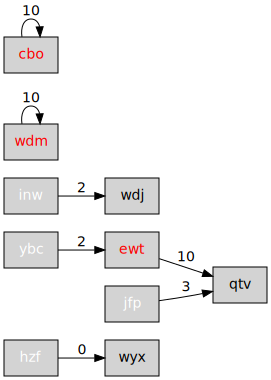

1


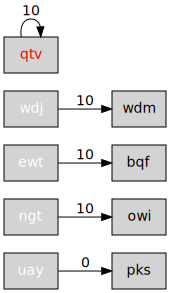

2


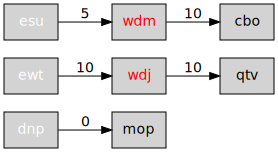

3


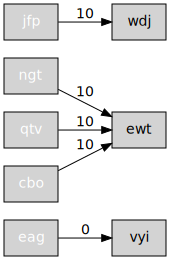

4


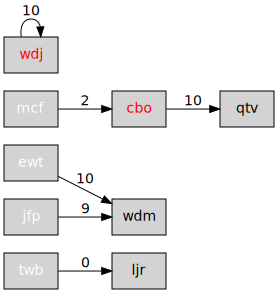

5


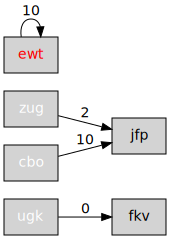

6


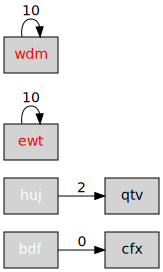

7


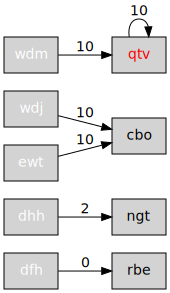

8


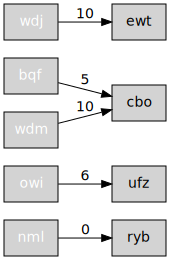

9


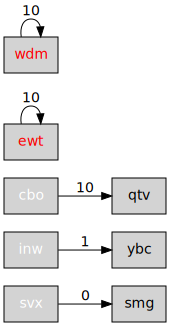

10


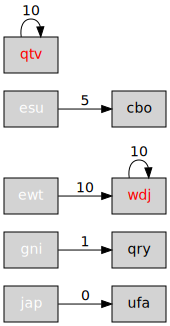

11


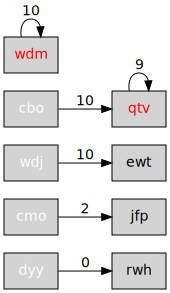

12


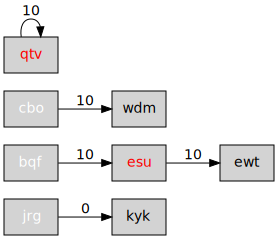

13


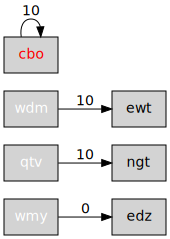

14


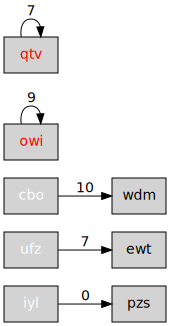

15


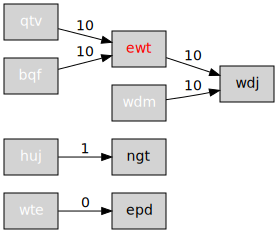

16


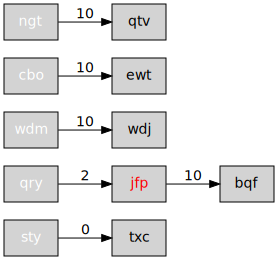

17


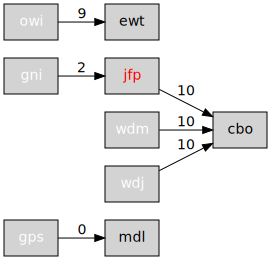

18


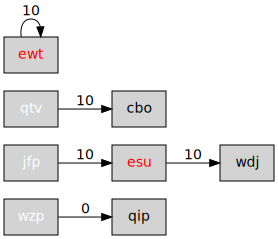

19


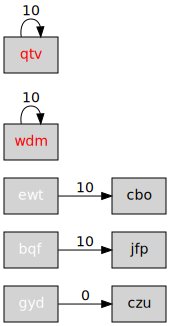

In [17]:
import graphviz
i = 0
for a in b.agents:
    print(i)
    g = a.plot_topology()
    display.display(g)
    i = i+1

In [24]:
g = b.agents[0].plot_topology()
g.graph_attr['rankdir'] = 'TB' 
g.render("CAgTopology.pdf")

'CAgTopology.pdf.pdf'

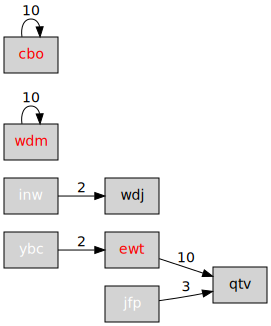

In [22]:
b.agents[0].plot_topology()

### Agents' topology ###
A CAg starts with a disconnected graph linking each detector to an effector.
The adapting iterative process creates a more complex, connected topology. Figure shows a typical CAg's topology. In the nodes, white and black labels represent respectively detectors and effectors. Red labels show nodes (types) that are both on the detector and effector side. An emerging feature is looping. The type *eek* is present both as a detector and as an effector type. This implements a "copier" behaviour: on a signal detection, the agent respond by replicating the same signal. Alos, it means that an agent is able to respond to its own behavior. Another interesting behavior appears with *lat*: it is associated to *tam* as its effector, but there is also *lat* detector associated to *phr* effector. This can lead to a longer auto-response chain, leading *tam* to *prh*. In turn, at the end of the chain there is also a *prh* looping detector. 
The number of sign functions is limited by the threshold (here with a default value of $10$) but it can be observed that in generally it is rarely required, as the agents do not require to store a a large inventory of sign functions. The sign function $dmc \to hyr$ is assigned a $0$ relevance. As new functions are given a $1$ value, this means that it was created at init time. 
In the second agent, the topology shows that both effectors *ttg* and *eek* are linked to (looping) *lat*. This means that different signals are responded in the same way, i.e. synonimy. In the model, homonimy (a detector linking to more effectors) is forbidden by construction, as one a suitable detector is found the CAg triggers the relative effector.

### Band's topology ###
The topology of a band can be described by linking signals in CEnv to CAgs. Given a signal, if a CAg has a detector for it then a directed edge is drawn from the signal to the agent, if the CAg has an effector for it then the directed edge goes from CAg to signal.
The initial topology of a band is trivial as it consist of completely disconnected signals and CAgs. While running, a band's topology quickly increases the connectivity, measured as the ratio edges/vertices in the graph, and typically assumes the form in Figure. Signals are drawn with note-shaped vertices while circles represent CAgs. Multiple edges between a signal and a CAg indicate that the CAg is able to generate the same signal once triggered by the different signals (synonimy). Note that there is only one input edge for each CAg (forbidden homonimy).
The band topology result in a complex circuit that keeps on reading/writing (so to say) the CEnv. This increase in connectivity with the creation of circuits reminds the discussion on autocalytic sets by Kaufman (see Steels 1996).

### The environment ###
The enviroment shown in Figure is the result of the last interaction. A CEnv changes at every interaction. Progressively, its redundancy tends to increase. This can be clearly seen by taking into account the $tp : tk$ ratio, that is the number of signal types against their occurrences in an environment. In Figure we consider bands having a population size from 10 to 100 agents, with a step of 10. For each size, we create 100 bands, run them for 10000 turns, and calculate the average ratio. As shown in Figure, the slope of the initial decrease depends on the band size, but in all cases the ratio seems to converge around $0.3$. This means an average of 3 occurrences for each signal type.


## Sharedness ##

In [ ]:
b.remove_zero_values()
d = b.get_sf_dict()
g = b.plot_sharedness(d)
g.render("bandTopology.pdf")

'bandTopology.pdf.pdf'

In [41]:
i = 0
for a in b.agents:
    print(i)
    sf = a.get_sf()
    if ['wdm', 'cbo'] in sf:
        print("suca")
        print(sf)
    i = i+1

0
1
2
suca
[['ewt', 'wdj'], ['esu', 'wdm'], ['wdj', 'qtv'], ['wdm', 'cbo']]
3
4
5
6
7
8
suca
[['owi', 'ufz'], ['bqf', 'cbo'], ['wdm', 'cbo'], ['wdj', 'ewt']]
9
10
11
12
13
14
15
16
17
suca
[['gni', 'jfp'], ['owi', 'ewt'], ['jfp', 'cbo'], ['wdm', 'cbo'], ['wdj', 'cbo']]
18
19


In [ ]:
b1 = Band(20)
vl = [sum([a.values for a in b1])]
sf = [len(a.get_sf())]
for x in range(1000):
    b.turn()
    for a in b1:
        vl = vl + [sum([a.values for a in b1])]
        sf = sf.append()
sf = [len(a.get_sf())]


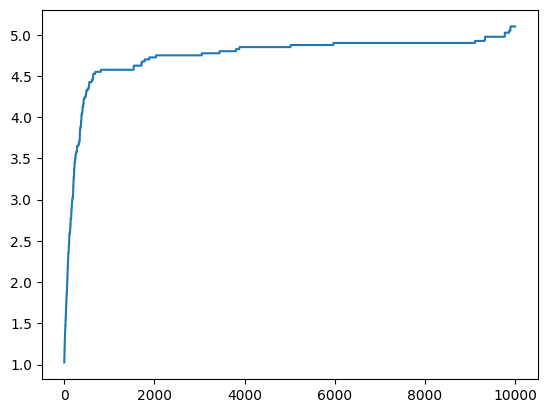

In [165]:
import numpy as np
n = 40
b1 = Band(n)
dt = []
for x in range(10000):
    vl = []
    sf = []
    b1.turn()
    #print([a.values for a in b1.agents])
    for a in b1.agents:
        for v in a.values:
            vl.append(v)
    #print(sum(vl))
    for  k in [a.get_sf() for a in b1.agents]:
        for s in k:
            sf.append(s)
    #dt.append(sum(vl)/len(sf))
    dt.append(len(sf)/n)
    #print(sum(vl), len(sf), sum(vl)/len(sf))

plt.plot(dt)

In [155]:
v = []
for a in b.agents:
    v = v + a.values

In [54]:
vs = set(v)

In [57]:
for i in range(11):
    print(i, v.count(i))

0 0
1 3
2 9
3 1
4 0
5 3
6 1
7 2
8 0
9 4
10 63
